### Libraries:

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Q1,2:

In [76]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1, as_frame=True)

X = boston.data
y = boston.target
print("Data Columns:")
print(X.info())
print()
print("----------------------------------------------------")
print()
print("Target Column:")
print(y.info())

Data Columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
dtypes: category(2), float64(11)
memory usage: 45.1 KB
None

----------------------------------------------------

Target Column:
<class 'pandas.core.series.Series'>
RangeIndex: 506 entries, 0 to 505
Series name: MEDV
Non-Null Count  Dtype  
--------------  -----  
506 non-null    float64
dtypes

### Q4:

In [77]:
from sklearn . model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2 )

### Q5:


In [78]:
pearsons_coefficient = np.corrcoef(y, X["AGE"])
print("The pearson's coeffient of the x and y inputs are: \n" ,pearsons_coefficient[0][1])

The pearson's coeffient of the x and y inputs are: 
 -0.3769545650045959


a correlation coefficient between -0.3 and -0.49 suggests moderate correlation

### Q6:

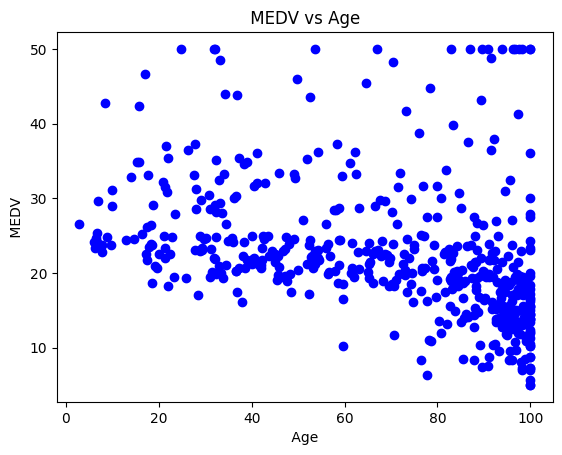

In [79]:
plt. scatter (X["AGE"] , y,color = 'blue' )
plt. title ( ' MEDV vs Age ' )
plt. xlabel ( ' Age ' )
plt. ylabel ( ' MEDV ' )
plt. show ()

### Q7:


In [80]:
pearsons_coefficient = np.corrcoef(y, X["LSTAT"])
print("The pearson's coeffient of the x and y inputs are: \n" ,pearsons_coefficient[0][1])

The pearson's coeffient of the x and y inputs are: 
 -0.7376627261740145


a correlation coefficient between -0.5 and -1 suggests strong correlation

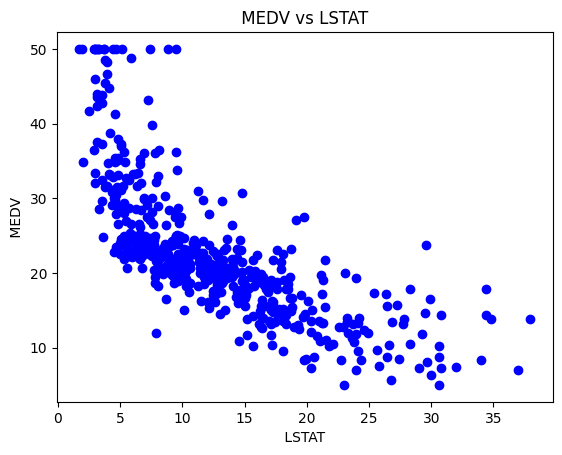

In [81]:
plt. scatter (X["LSTAT"] , y,color = 'blue' )
plt. title ( ' MEDV vs LSTAT ' )
plt. xlabel ( ' LSTAT ' )
plt. ylabel ( ' MEDV ' )
plt. show ()

### Q8:

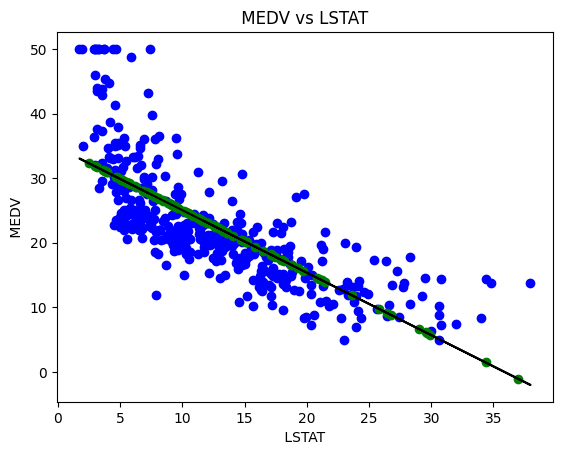

In [82]:
X_train_lstat=X_train.LSTAT.values.reshape(-1, 1)
X_test_lstat=X_test.LSTAT.values.reshape(-1, 1)
from sklearn . linear_model import LinearRegression
regressor = LinearRegression ()
regressor.fit ( X_train_lstat, y_train)

y_true = y_test
y_pred = regressor.predict(X_test_lstat)

plt. scatter (X_train_lstat, y_train, color = 'blue' )
plt. scatter (X_test_lstat, y_pred, color = 'green' )
plt. plot (X_train_lstat, regressor. predict (X_train_lstat), color = 'black' )
plt. title ( ' MEDV vs LSTAT ' )
plt. xlabel ( ' LSTAT ' )
plt. ylabel ( ' MEDV ' )
plt. show ()

### Q9:

In [83]:
rse = regressor.score(X_train_lstat, y_train)
print()
print(f"(R-squared) Score/accuracy: {rse:.4f}")
print()


(R-squared) Score/accuracy: 0.5621



the graph shows that the regression line does not quite cover all the values as they seems to be in the shape of a curve rather than a line so a simple linear regression with just Lstat wont be as accurate as a model that contains more parameters or a model that is polynomial.
the high error rate of almost 50% also suggests that the model is not optimal.

### Q10:
we need to use a polynomial regression.

### Q11:

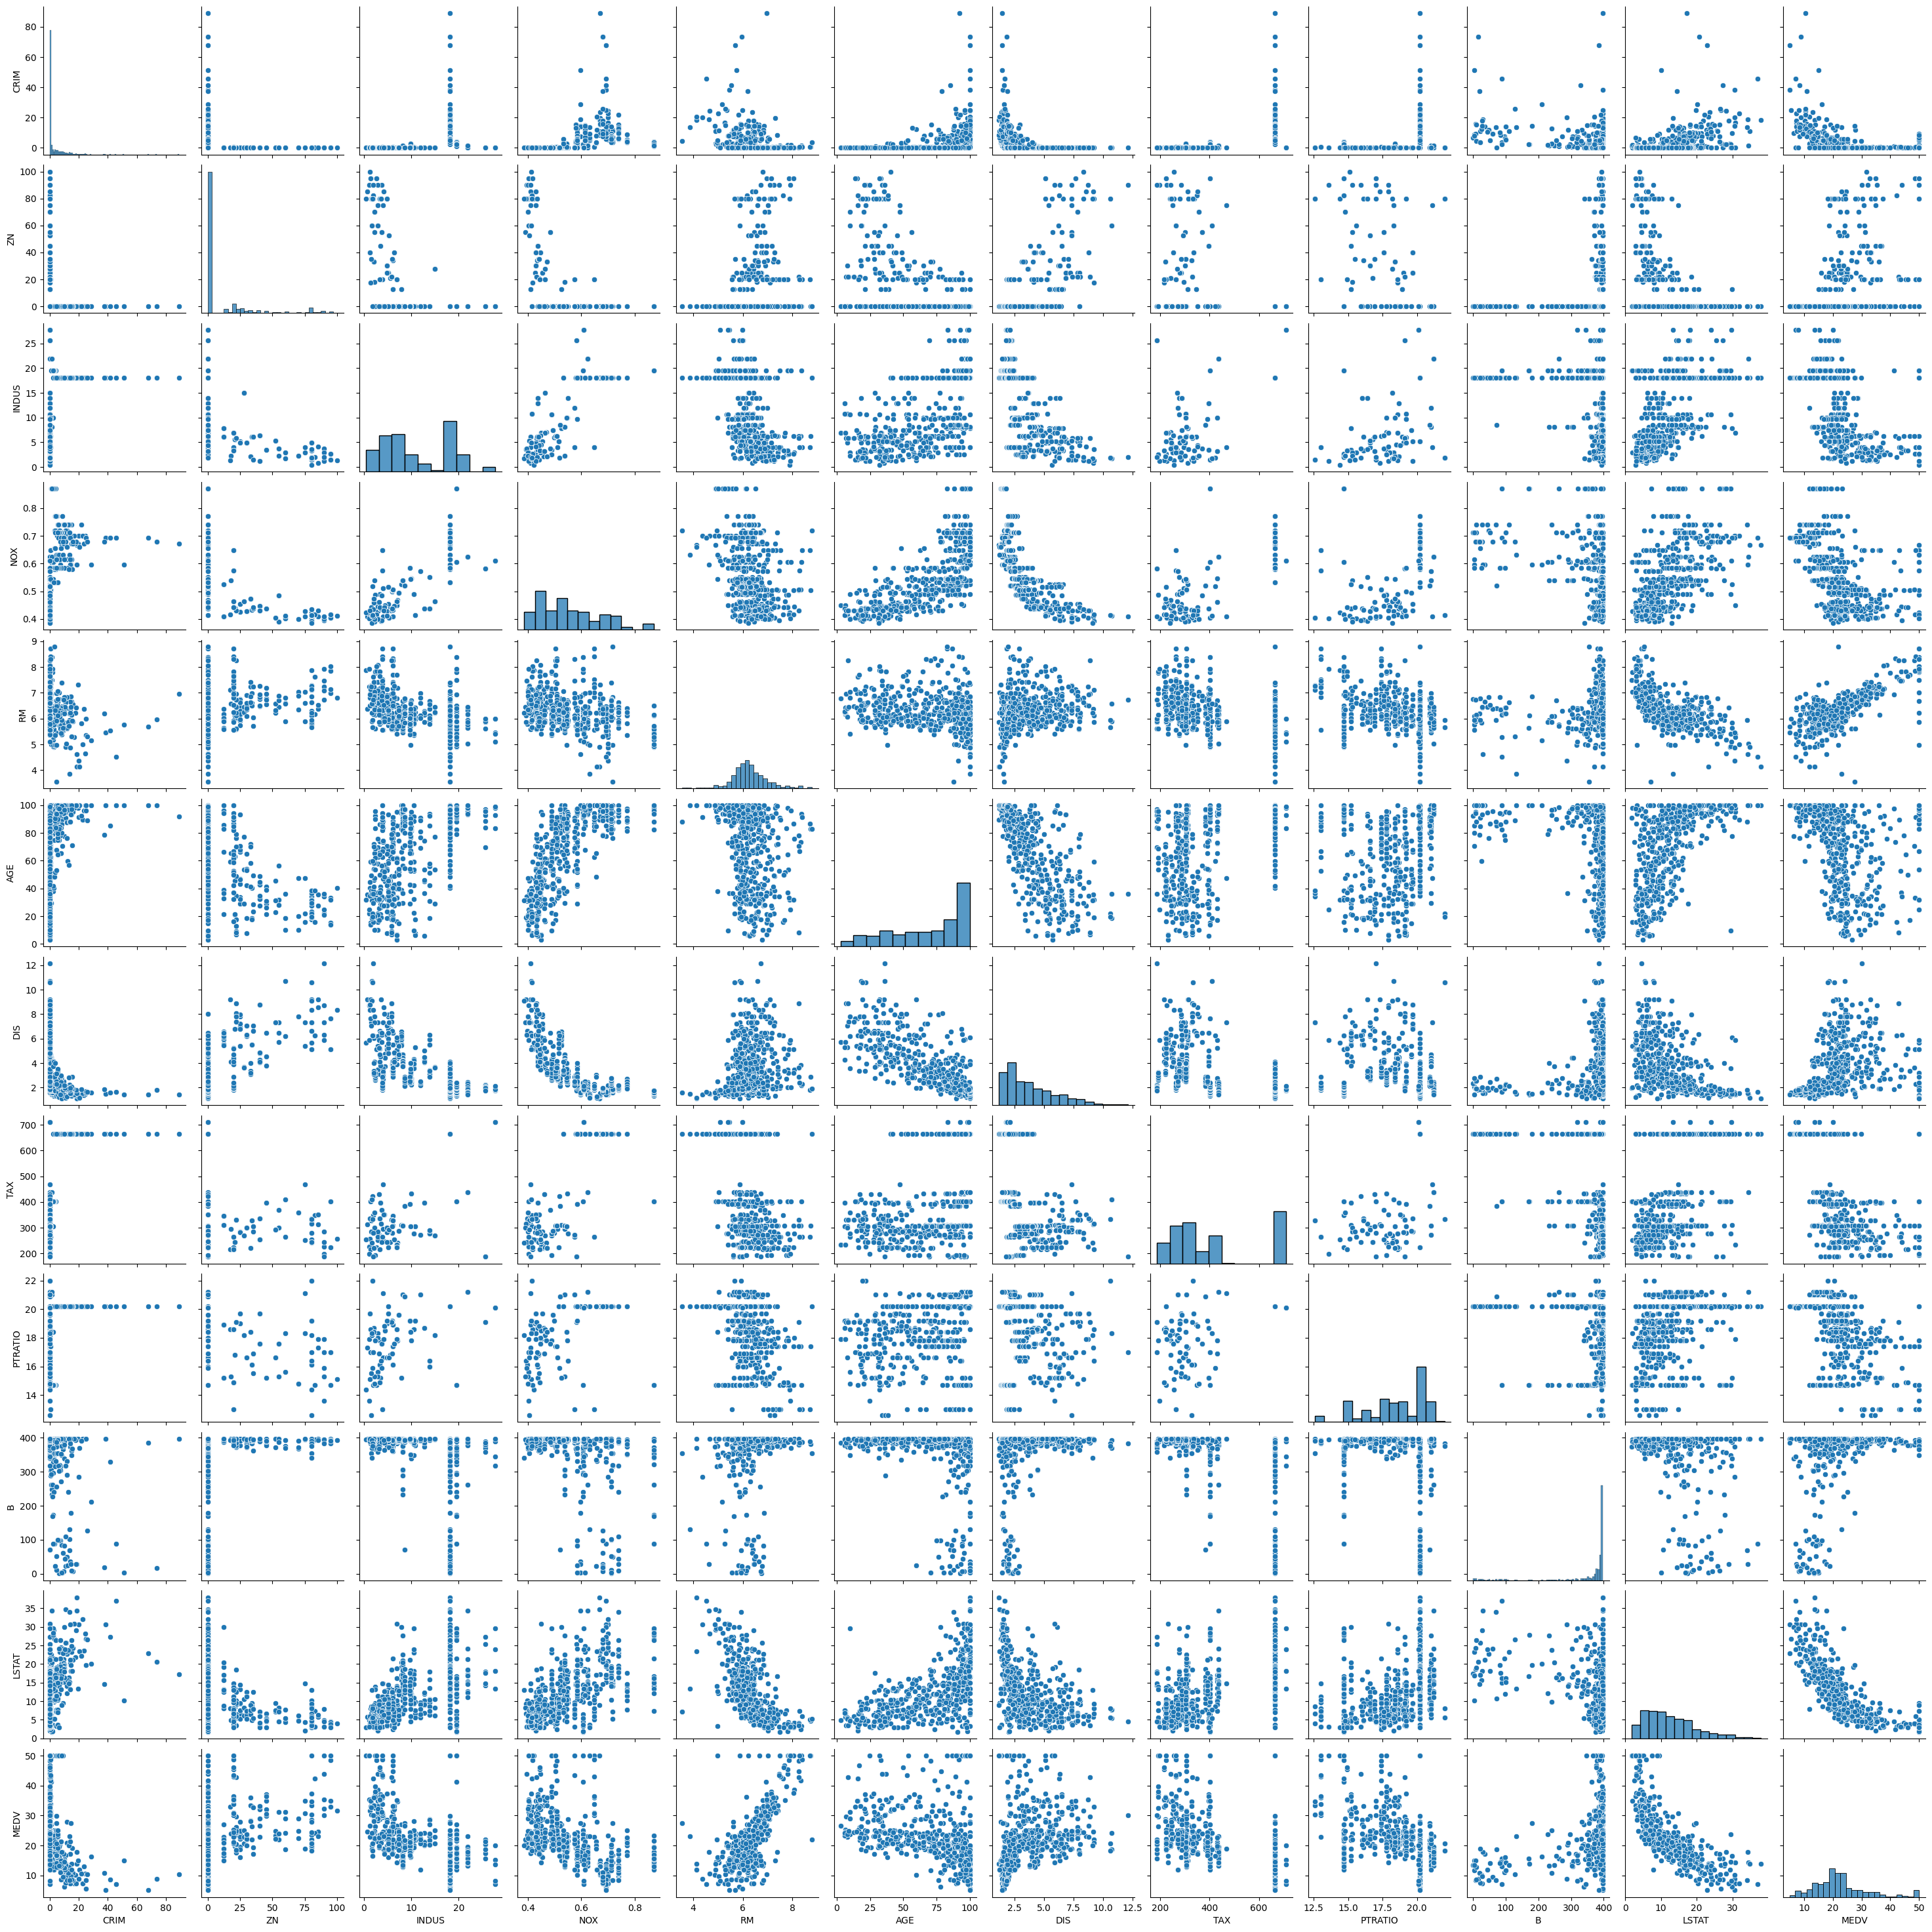

In [84]:
import seaborn as sns

boston_df = pd.DataFrame(boston.data, columns=boston.feature_names)

boston_df['MEDV'] = boston.target


sns.pairplot(boston_df)

this plots each column in function of all the other columns resulting in N*N graphs if N is the nulber of columns.

### Q12:

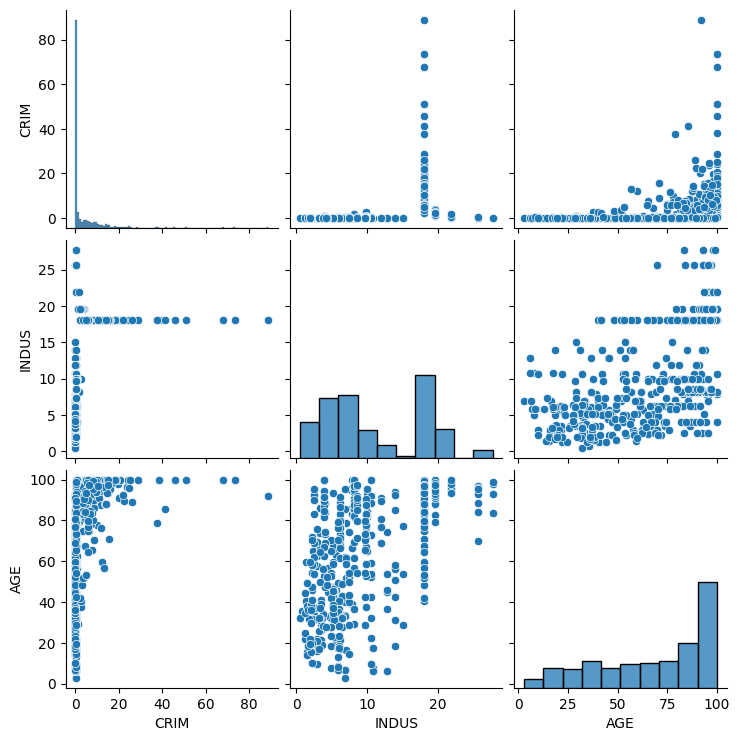

In [85]:
indices=[0,2,6]

q12_df=boston_df.iloc[:, indices]

sns.pairplot(q12_df)

### Q13:


In [86]:
desired_columns = ['LSTAT', 'AGE']

q13_X_train = X_train[desired_columns]
q13_regressor = LinearRegression ()
q13_regressor.fit ( q13_X_train, y_train)
print(f"(R-squared) Score/accuracy : {q13_regressor.score( q13_X_train, y_train):.4f}")

(R-squared) Score/accuracy : 0.5729


### Q14:
high error rate means this is not the suitable set of explanatory variables to use. we need to introduce more variables or use a polynomial regression.

### Q15:


In [ ]:
desired_columns = ['LSTAT', 'AGE']

q14_X_train = X_train[desired_columns].copy()
q14_X_train["LSTAT"]=np.log(q14_X_train["LSTAT"])
q14_X_train["AGE"]=np.log(q14_X_train["AGE"])
q14_regressor = LinearRegression ()
q14_regressor.fit ( q14_X_train, y_train)
print(f"(R-squared) Score/accuracy : {q14_regressor.score( q14_X_train, y_train):.4f}")

RSE : 0.7157


### Q16:
even though we used the logarithm of the variables the error is still high (30%), if handling the extreme values does not help it, it means we are using the wrong variables.

### Q17:

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler 

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['category']).columns.tolist()

ct = ColumnTransformer(
    transformers=[

        ('onehot', 
         OneHotEncoder(handle_unknown='ignore'), 
         categorical_features)
    ],

    remainder='passthrough'
)

X_transformed = ct.fit_transform(X)
X_array = np.array(X_transformed) 

new_feature_names = ct.get_feature_names_out().tolist()


X_labeled_df = pd.DataFrame(
    X_array, 
    columns=new_feature_names
)

# non_category_df = X.select_dtypes(exclude=['category'])



header_list = X_labeled_df.columns

p_values_dict = {}
ALPHA=0.05
from scipy.stats import pearsonr

for header in header_list:
    correlation_coefficient, p_value = pearsonr(X_labeled_df[header], y)
    print(f"The pearson's coeffient of {header} and MEDV is:  {correlation_coefficient:.4f}")
    print(f"The p-value of {header} and MEDV is:              {p_value}")
    if p_value <= ALPHA:

        p_values_dict[header] = p_value
    


The pearson's coeffient of onehot__CHAS_0 and MEDV is:  -0.1753
The p-value of onehot__CHAS_0 and MEDV is:              7.390623170519845e-05
The pearson's coeffient of onehot__CHAS_1 and MEDV is:  0.1753
The p-value of onehot__CHAS_1 and MEDV is:              7.390623170519845e-05
The pearson's coeffient of onehot__RAD_1 and MEDV is:  0.0405
The p-value of onehot__RAD_1 and MEDV is:              0.36383566165942444
The pearson's coeffient of onehot__RAD_2 and MEDV is:  0.1044
The p-value of onehot__RAD_2 and MEDV is:              0.018772259117401532
The pearson's coeffient of onehot__RAD_24 and MEDV is:  -0.3963
The p-value of onehot__RAD_24 and MEDV is:              1.7778938603225865e-20
The pearson's coeffient of onehot__RAD_3 and MEDV is:  0.1674
The p-value of onehot__RAD_3 and MEDV is:              0.00015564774500138607
The pearson's coeffient of onehot__RAD_4 and MEDV is:  -0.0657
The p-value of onehot__RAD_4 and MEDV is:              0.1399272272403497
The pearson's coeffien

all the variables show moderate to high correlation with MEDV except for DIS. and the significance varies since the usual p-value used for significance is less than 0.05.

### Q18:
we can conclude that MEDV may depend on more than LSTAT and AGE since the other variables show similar if not higher correlation to it.

### Q19:


In [ ]:

significant_features = list(p_values_dict.keys())

X_significant_df = X_labeled_df[significant_features]

X_train, X_test, y_train, y_test = train_test_split (X_significant_df, y, test_size = 0.2 )

regressor = LinearRegression ()
regressor.fit ( X_train , y_train )
y_pred = regressor. predict ( X_test )

print(f"(R-squared) Score/accuracy : {regressor.score( X_train, y_train):.4f}")



RSE : 0.7400


### Q20:
we can conclude that no matter what we do with the data a linear model just is not the right solution, so we must try a nonlinear option.

### Q21:

In [ ]:
desired_columns = ['remainder__LSTAT', 'remainder__AGE']

q21_X_train = X_train[desired_columns].copy()
q21_X_train["INTERACT"]= q21_X_train["remainder__AGE"] * q21_X_train["remainder__LSTAT"]

q21_regressor = LinearRegression ()
q21_regressor.fit ( q21_X_train, y_train)
print(f"(R-squared) Score/accuracy : {q21_regressor.score( q21_X_train, y_train):.4f}")

RSE : 0.5683


### Q22:

In [ ]:
from sklearn . preprocessing import PolynomialFeatures
from sklearn . linear_model import LinearRegression

degrees=[ 2, 3, 4, 5, 6 ,7]

for d in degrees:
    poly_reg = PolynomialFeatures (degree = d )
    X_poly = poly_reg. fit_transform ( X_train )
    X_test_poly = poly_reg. fit_transform ( X_test )
    lin_reg = LinearRegression ()
    lin_reg.fit ( X_poly, y_train )
    y_pred = lin_reg. predict ( X_poly )
    print(f"(R-squared) Score/accuracy for degree {d}: {lin_reg.score( X_poly, y_train):.4f}")


RSE for degree 2: 0.8269
RSE for degree 3: 1.0000
RSE for degree 4: 1.0000
RSE for degree 5: 1.0000
RSE for degree 6: 1.0000
RSE for degree 7: 1.0000


### Q23:
we can conclude that a polynomial model of degree 2 is the best fit for our data since every subsequent degree has an accuracy of 100% and the simple linear models all had lower accuracies.